In [1]:
# ── CELL 1: Imports ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ── CELL 2: Load saved datasets ───────────────────────────────
df      = pd.read_csv('../outputs/master_dataset.csv')
df2024  = pd.read_csv('../outputs/dataset_2024.csv')
sl      = pd.read_csv('../outputs/srilanka_data.csv')

print(f"Master dataset : {df.shape[0]} rows | {df['name'].nunique()} countries")
print(f"2024 snapshot  : {df2024.shape[0]} rows")
print(f"Sri Lanka rows : {len(sl)}")

Master dataset : 5594 rows | 233 countries
2024 snapshot  : 211 rows
Sri Lanka rows : 25


In [3]:
# ── CELL 3: Prepare the ML working dataset ────────────────────
# Strategy: use countries that have ALL THREE indicators in 2024
# This gives us the cleanest, most defensible dataset for ML

df_ml = df2024[['name','iso3','region_income','region_sdg',
                 'region_ldc','region_sids','prop_u',
                 'wat_basal_t','san_basal_t','hyg_bas_t',
                 'wat_basal_r','wat_basal_u',
                 'san_basal_r','san_basal_u',
                 'arc_wat_basal_t','arc_san_basal_t']].copy()

# Drop rows missing any of the 3 core WASH indicators
df_ml = df_ml.dropna(subset=['wat_basal_t','san_basal_t','hyg_bas_t'])
df_ml = df_ml.reset_index(drop=True)

print(f"Countries with all 3 WASH indicators (2024): {len(df_ml)}")
print(f"\nIncome group breakdown:")
print(df_ml['region_income'].value_counts())
print(f"\nSDG region breakdown:")
print(df_ml['region_sdg'].value_counts())

# Check Sri Lanka is included
sl_in_ml = df_ml[df_ml['name'] == 'Sri Lanka']
print(f"\nSri Lanka in ML dataset: {'YES' if len(sl_in_ml) > 0 else 'NO'}")
if len(sl_in_ml) > 0:
    print(sl_in_ml[['name','wat_basal_t','san_basal_t','hyg_bas_t']].to_string(index=False))

Countries with all 3 WASH indicators (2024): 88

Income group breakdown:
region_income
Lower middle income    38
Upper middle income    23
Low income             20
High income             7
Name: count, dtype: int64

SDG region breakdown:
region_sdg
Sub-Saharan Africa                  33
Northern Africa and Western Asia    13
Latin America and the Caribbean     13
Central and Southern Asia           10
Eastern and South-Eastern Asia       9
Oceania                              8
Europe and Northern America          2
Name: count, dtype: int64

Sri Lanka in ML dataset: YES
     name  wat_basal_t  san_basal_t  hyg_bas_t
Sri Lanka    90.213844    95.353021  87.694348


In [4]:
# ── CELL 4: PCA-Weighted MPRI ─────────────────────────────────
# This is your key scientific contribution over the other proposal.
# Instead of arbitrary weights (0.4, 0.3, 0.3), we derive weights
# mathematically from PCA — fully defensible to IEEE reviewers.

features = ['wat_basal_t', 'san_basal_t', 'hyg_bas_t']
feature_labels = ['Water Access', 'Sanitation', 'Hygiene']

# Step 1: Normalize features to 0-1
scaler_features = MinMaxScaler()
X_scaled = scaler_features.fit_transform(df_ml[features])

# Step 2: Run PCA with 1 component to find dominant variance direction
pca = PCA(n_components=1, random_state=42)
pca.fit(X_scaled)

# Step 3: Derive weights from absolute PCA loadings
loadings = np.abs(pca.components_[0])
weights  = loadings / loadings.sum()   # normalize so weights sum to 1

print("=" * 50)
print("PCA-Derived Feature Weights for MPRI")
print("=" * 50)
for feat, w in zip(feature_labels, weights):
    print(f"  {feat:<20}: {w:.4f}  ({w*100:.1f}%)")
print(f"\n  Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print("  (Higher = features are strongly aligned — good for MPRI)")

# Step 4: Compute MPRI
# MPRI = weighted deficit in WASH access
# (100 - indicator) means higher MPRI = higher marine pollution risk
df_ml['MPRI_raw'] = (
    weights[0] * (100 - df_ml['wat_basal_t']) +
    weights[1] * (100 - df_ml['san_basal_t']) +
    weights[2] * (100 - df_ml['hyg_bas_t'])
)

# Step 5: Rescale MPRI to 0-100 for interpretability
scaler_mpri = MinMaxScaler(feature_range=(0, 100))
df_ml['MPRI'] = scaler_mpri.fit_transform(df_ml[['MPRI_raw']]).flatten()

print("\n" + "=" * 50)
print("MPRI Distribution Summary")
print("=" * 50)
print(df_ml['MPRI'].describe().round(2))

# Sri Lanka position
sl_mpri = df_ml[df_ml['name'] == 'Sri Lanka']['MPRI'].values[0]
sl_rank = (df_ml['MPRI'].rank(ascending=False)[df_ml['name']=='Sri Lanka']).values[0]
print(f"\nSri Lanka MPRI score : {sl_mpri:.2f} / 100")
print(f"Sri Lanka global rank: {int(sl_rank)} of {len(df_ml)} countries")
print(f"(Rank 1 = highest marine pollution risk)")

PCA-Derived Feature Weights for MPRI
  Water Access        : 0.2692  (26.9%)
  Sanitation          : 0.3630  (36.3%)
  Hygiene             : 0.3678  (36.8%)

  Variance explained by PC1: 90.2%
  (Higher = features are strongly aligned — good for MPRI)

MPRI Distribution Summary
count     88.00
mean      37.51
std       31.71
min        0.00
25%        8.67
50%       23.39
75%       67.93
max      100.00
Name: MPRI, dtype: float64

Sri Lanka MPRI score : 11.16 / 100
Sri Lanka global rank: 61 of 88 countries
(Rank 1 = highest marine pollution risk)


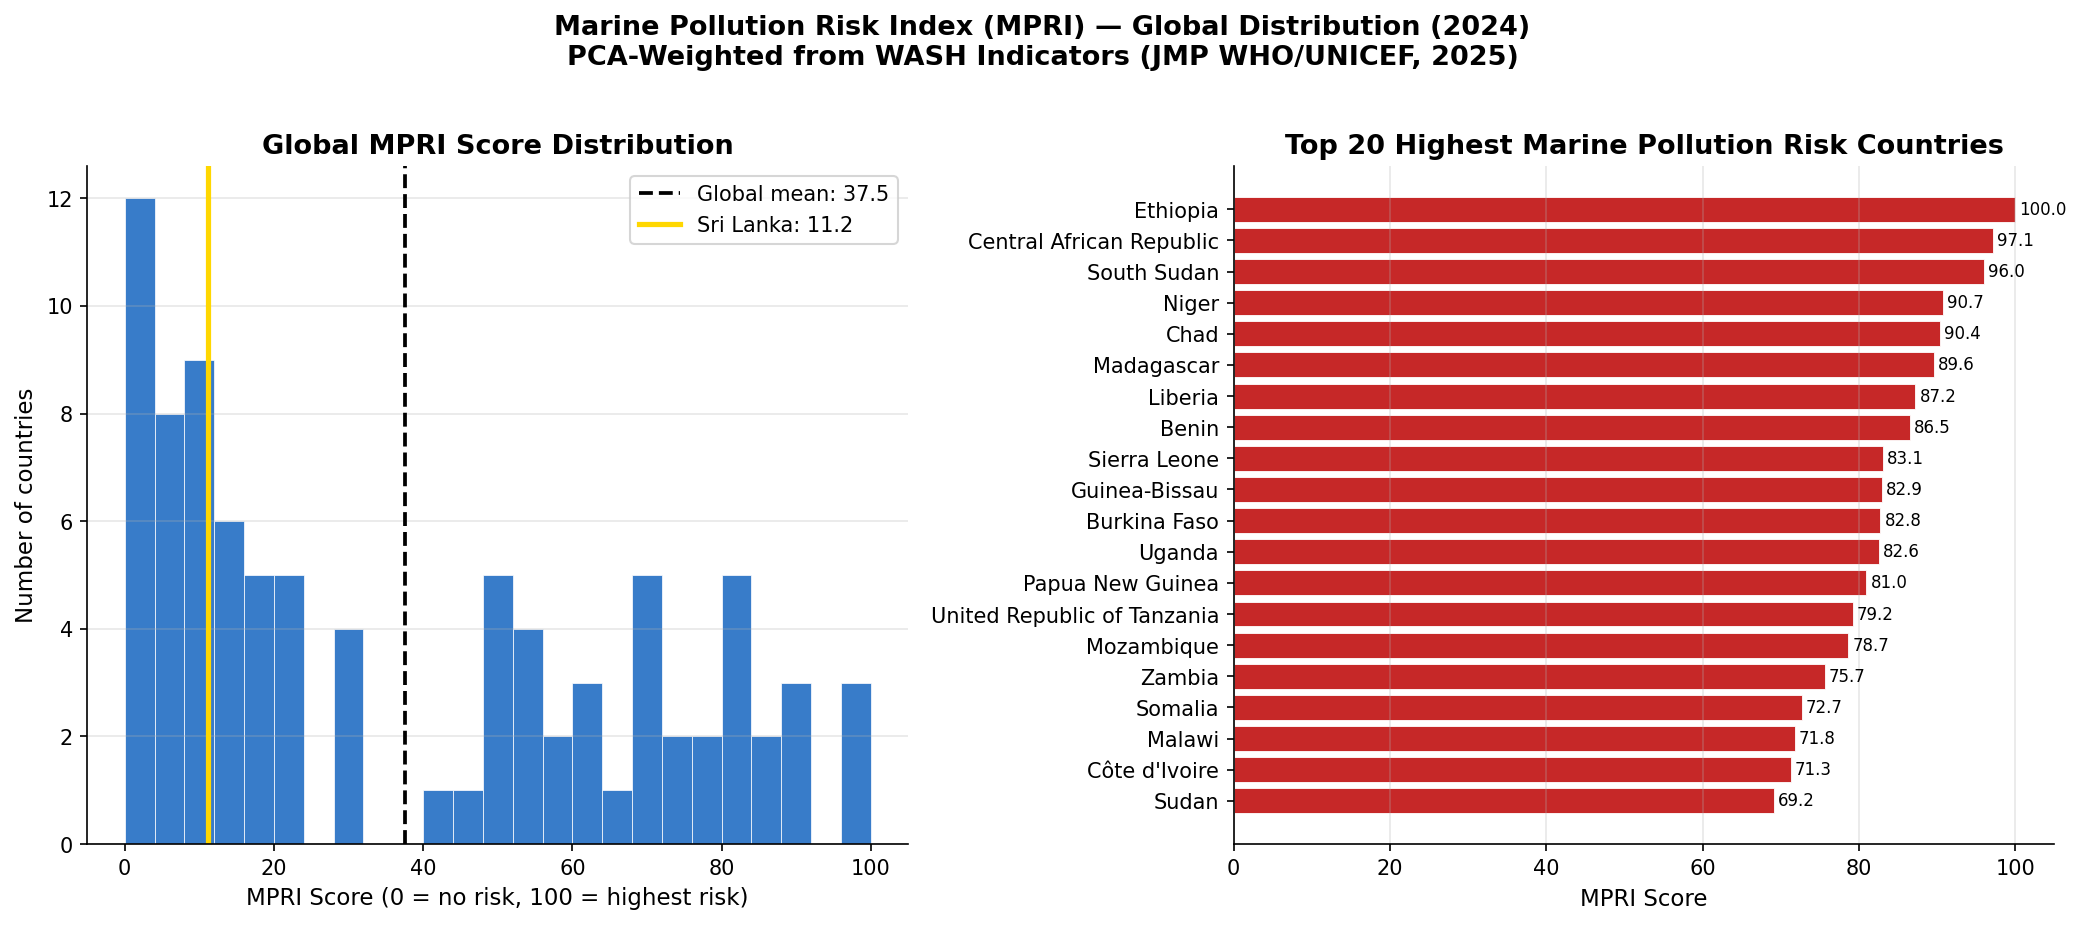

Saved: figures/fig6_mpri_distribution.png


In [5]:
# ── CELL 5: Figure 6 — MPRI Distribution + Sri Lanka ──────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Marine Pollution Risk Index (MPRI) — Global Distribution (2024)\n'
             'PCA-Weighted from WASH Indicators (JMP WHO/UNICEF, 2025)',
             fontsize=13, fontweight='bold', y=1.02)

# Panel A: Histogram of MPRI
ax1.hist(df_ml['MPRI'], bins=25, color='#1565C0', edgecolor='white',
         alpha=0.85, linewidth=0.4)
ax1.axvline(df_ml['MPRI'].mean(), color='black', linestyle='--',
            linewidth=1.8, label=f"Global mean: {df_ml['MPRI'].mean():.1f}")
ax1.axvline(sl_mpri, color='gold', linestyle='-', linewidth=2.5,
            label=f"Sri Lanka: {sl_mpri:.1f}")
ax1.set_xlabel('MPRI Score (0 = no risk, 100 = highest risk)', fontsize=11)
ax1.set_ylabel('Number of countries', fontsize=11)
ax1.set_title('Global MPRI Score Distribution', fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# Panel B: Top 20 highest-risk + Sri Lanka highlighted
top20 = df_ml.nlargest(20, 'MPRI')[['name','MPRI']].sort_values('MPRI')
colors_bar = ['gold' if n == 'Sri Lanka' else '#C62828' for n in top20['name']]
bars = ax2.barh(top20['name'], top20['MPRI'], color=colors_bar,
                edgecolor='white', linewidth=0.4)
ax2.set_xlabel('MPRI Score', fontsize=11)
ax2.set_title('Top 20 Highest Marine Pollution Risk Countries', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)
# Annotate values
for bar, val in zip(bars, top20['MPRI']):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../figures/fig6_mpri_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig6_mpri_distribution.png")

k | Inertia    | Silhouette
-----------------------------------
2 |       6.99 | 0.6748
3 |       4.08 | 0.5997 ← selected
4 |       3.25 | 0.4420
5 |       2.53 | 0.4232
6 |       2.18 | 0.4379
7 |       1.94 | 0.4111
8 |       1.72 | 0.4069


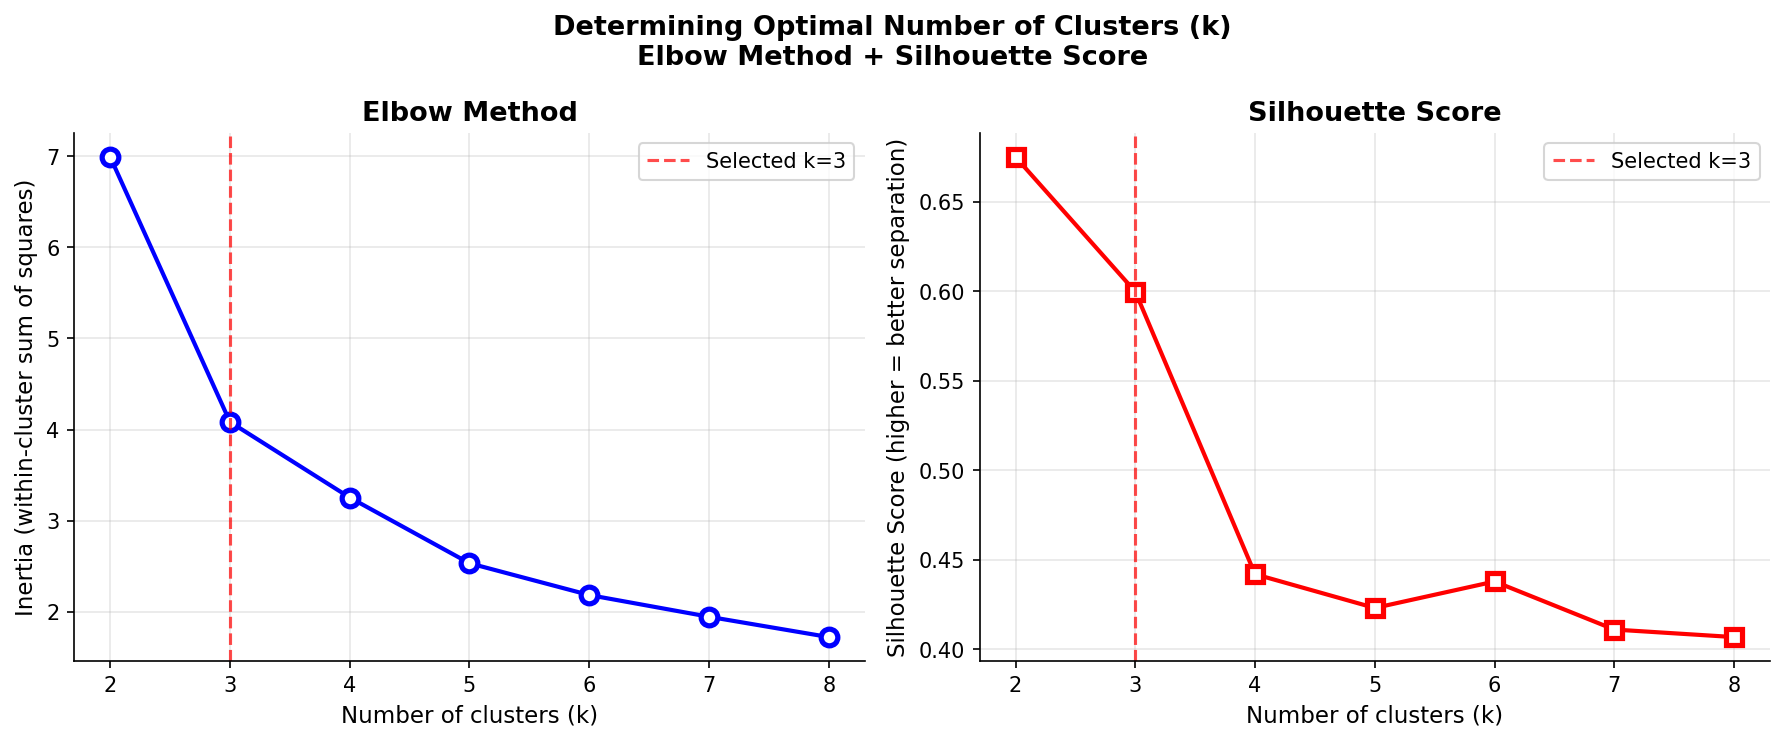

Saved: figures/fig7_optimal_k.png


In [6]:
# ── CELL 6: Elbow + Silhouette to find optimal k ──────────────
# Use all WASH features + MPRI for clustering
X_cluster = df_ml[['wat_basal_t','san_basal_t','hyg_bas_t','MPRI']].copy()

# Scale to 0-1 (MPRI is already 0-100, same range as others so consistent)
scaler_cluster = MinMaxScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

inertias   = []
sil_scores = []
K_range    = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Determining Optimal Number of Clusters (k)\n'
             'Elbow Method + Silhouette Score', fontsize=13, fontweight='bold')

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8,
         markerfacecolor='white', markeredgewidth=2.5)
ax1.axvline(3, color='red', linestyle='--', alpha=0.7, label='Selected k=3')
ax1.set_xlabel('Number of clusters (k)', fontsize=11)
ax1.set_ylabel('Inertia (within-cluster sum of squares)', fontsize=11)
ax1.set_title('Elbow Method', fontweight='bold')
ax1.set_xticks(list(K_range))
ax1.legend()
ax1.grid(alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

ax2.plot(K_range, sil_scores, 'rs-', linewidth=2, markersize=8,
         markerfacecolor='white', markeredgewidth=2.5)
ax2.axvline(3, color='red', linestyle='--', alpha=0.7, label='Selected k=3')
ax2.set_xlabel('Number of clusters (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score (higher = better separation)', fontsize=11)
ax2.set_title('Silhouette Score', fontweight='bold')
ax2.set_xticks(list(K_range))
ax2.legend()
ax2.grid(alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

# Print values
print("k | Inertia    | Silhouette")
print("-" * 35)
for k, inn, sil in zip(K_range, inertias, sil_scores):
    marker = " ← selected" if k == 3 else ""
    print(f"{k} | {inn:10.2f} | {sil:.4f}{marker}")

plt.tight_layout()
plt.savefig('../figures/fig7_optimal_k.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig7_optimal_k.png")

In [7]:
# ── CELL 7: Apply K-Means with k=3 ────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=42, n_init=15)
df_ml['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Label clusters by mean MPRI: lowest MPRI = Low Risk, highest = High Risk
cluster_means = df_ml.groupby('cluster')['MPRI'].mean().sort_values()
label_map = {
    cluster_means.index[0]: 'Low Risk',
    cluster_means.index[1]: 'Medium Risk',
    cluster_means.index[2]: 'High Risk'
}
df_ml['risk_category'] = df_ml['cluster'].map(label_map)

# Final silhouette score
final_sil = silhouette_score(X_cluster_scaled, df_ml['cluster'])

print("=" * 55)
print("K-Means Clustering Results (k=3)")
print("=" * 55)
print(f"Final Silhouette Score: {final_sil:.4f}")
print(f"  (>0.5 = good, >0.7 = strong cluster separation)")
print()

summary = df_ml.groupby('risk_category').agg(
    countries        = ('name', 'count'),
    mean_water       = ('wat_basal_t', 'mean'),
    mean_sanitation  = ('san_basal_t', 'mean'),
    mean_hygiene     = ('hyg_bas_t',   'mean'),
    mean_MPRI        = ('MPRI',        'mean'),
    min_MPRI         = ('MPRI',        'min'),
    max_MPRI         = ('MPRI',        'max'),
).round(2)

print(summary.to_string())

print()
print("=" * 55)
sl_risk = df_ml[df_ml['name']=='Sri Lanka']['risk_category'].values[0]
sl_mpri_score = df_ml[df_ml['name']=='Sri Lanka']['MPRI'].values[0]
print(f"Sri Lanka → Risk Category: {sl_risk}")
print(f"Sri Lanka → MPRI Score   : {sl_mpri_score:.2f}")
print("=" * 55)

K-Means Clustering Results (k=3)
Final Silhouette Score: 0.5997
  (>0.5 = good, >0.7 = strong cluster separation)

               countries  mean_water  mean_sanitation  mean_hygiene  mean_MPRI  min_MPRI  max_MPRI
risk_category                                                                                     
High Risk             15       57.91            22.55         19.70      87.18     78.66    100.00
Low Risk              49       95.63            91.21         86.89      11.59      0.00     29.30
Medium Risk           24       78.32            51.99         35.46      59.39     42.45     75.67

Sri Lanka → Risk Category: Low Risk
Sri Lanka → MPRI Score   : 11.16


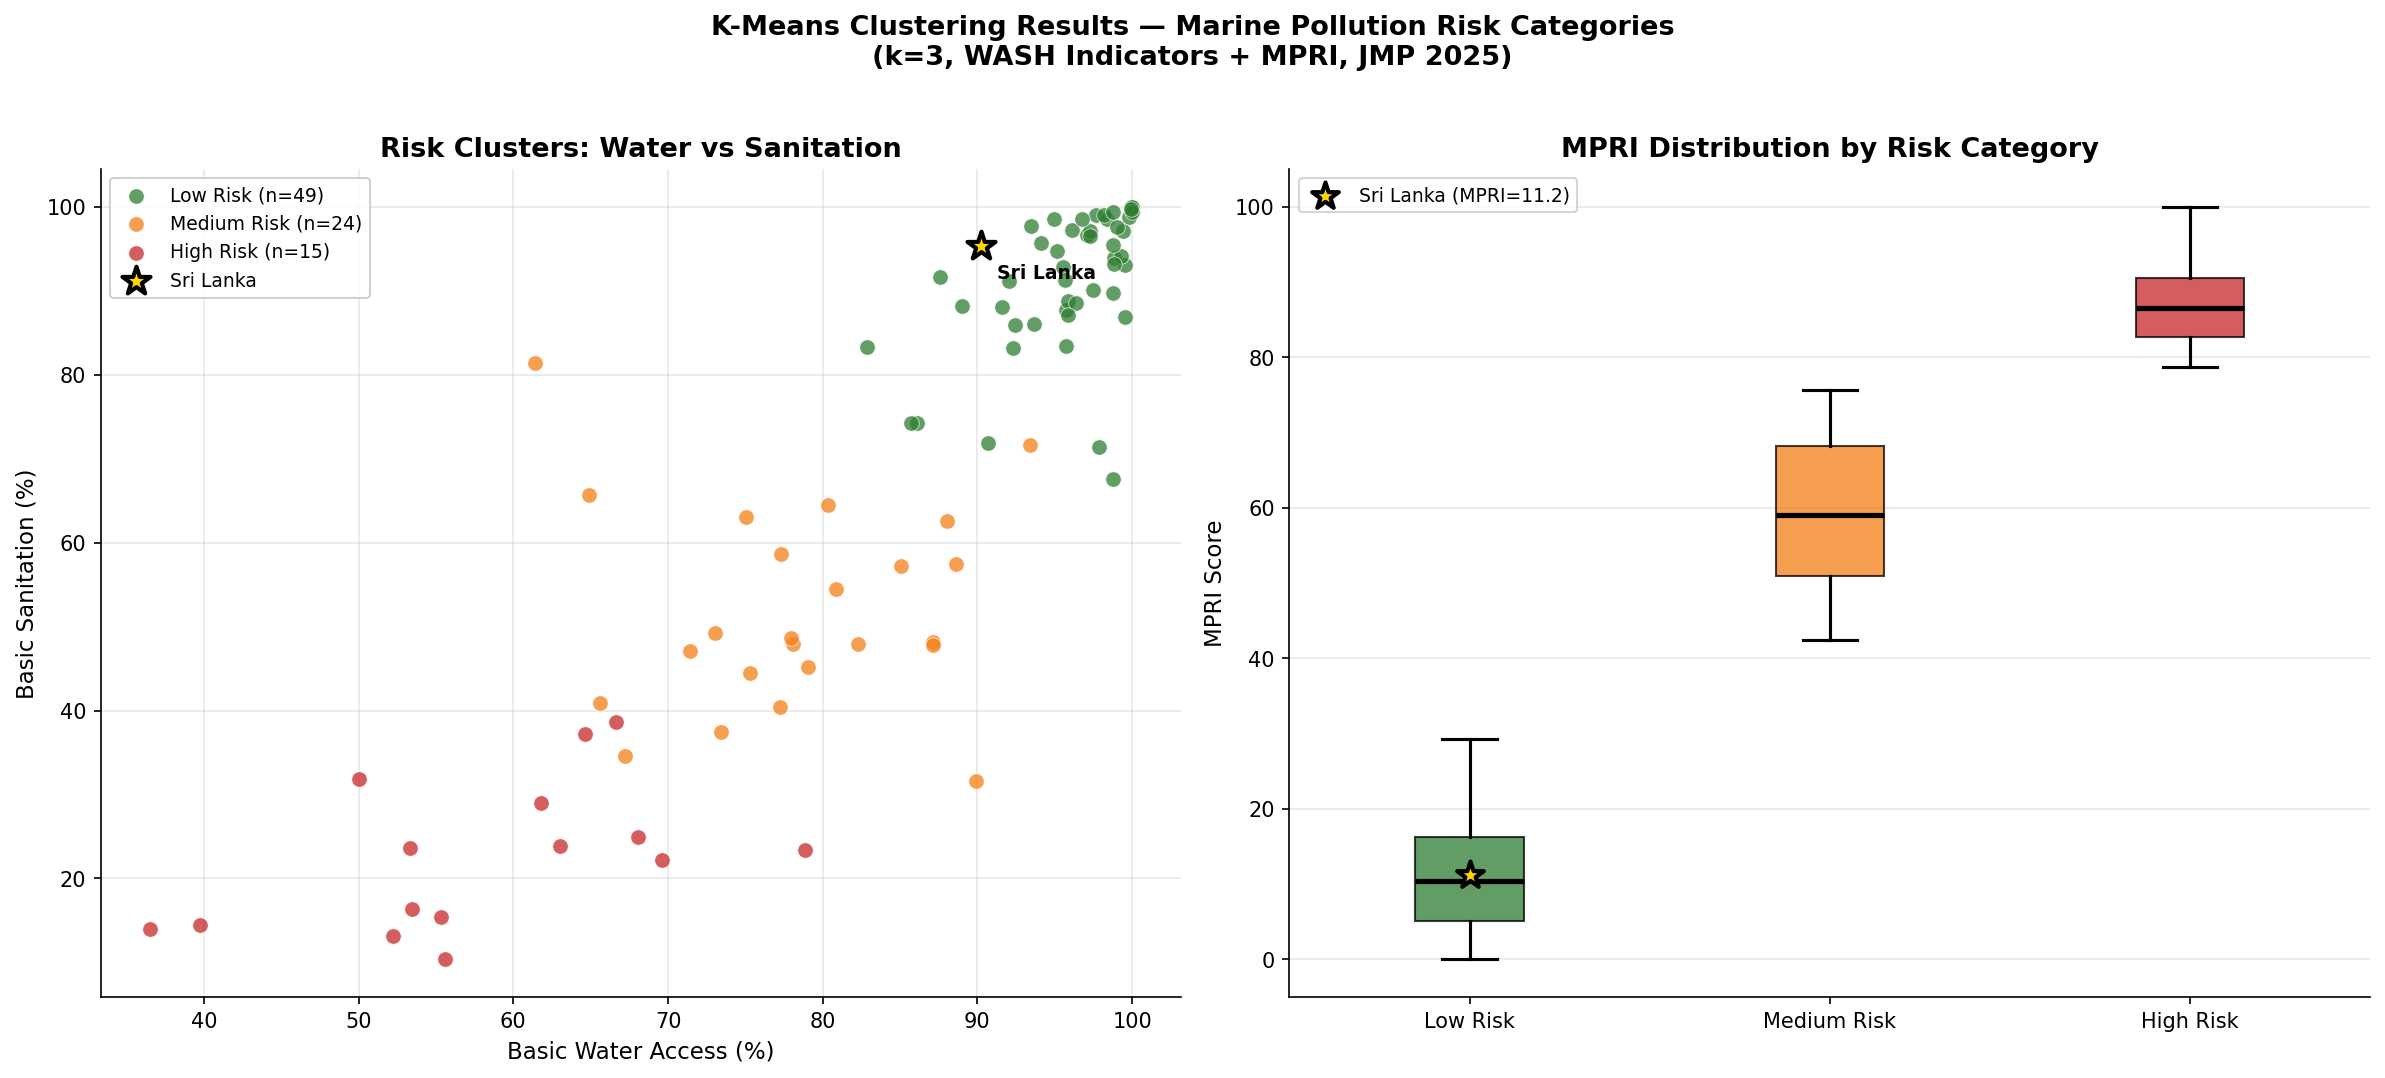

Saved: figures/fig8_cluster_results.png


In [8]:
# ── CELL 8: Figure 8 — Cluster visualisation ──────────────────
risk_colors = {'Low Risk': '#2E7D32', 'Medium Risk': '#F57F17', 'High Risk': '#C62828'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('K-Means Clustering Results — Marine Pollution Risk Categories\n'
             '(k=3, WASH Indicators + MPRI, JMP 2025)',
             fontsize=13, fontweight='bold', y=1.02)

# Panel A: Sanitation vs Water, coloured by cluster
ax = axes[0]
for risk_cat, color in risk_colors.items():
    subset = df_ml[df_ml['risk_category'] == risk_cat]
    ax.scatter(subset['wat_basal_t'], subset['san_basal_t'],
               c=color, label=f"{risk_cat} (n={len(subset)})",
               alpha=0.75, s=55, edgecolors='white', linewidths=0.4, zorder=3)

# Highlight Sri Lanka
sl_row = df_ml[df_ml['name']=='Sri Lanka']
sl_color = risk_colors[sl_row['risk_category'].values[0]]
ax.scatter(sl_row['wat_basal_t'], sl_row['san_basal_t'],
           c='gold', s=200, zorder=6, edgecolors='black',
           linewidths=2, marker='*', label='Sri Lanka')
ax.annotate('Sri Lanka',
            (sl_row['wat_basal_t'].values[0], sl_row['san_basal_t'].values[0]),
            xytext=(8, -16), textcoords='offset points',
            fontsize=9, fontweight='bold')

ax.set_xlabel('Basic Water Access (%)', fontsize=11)
ax.set_ylabel('Basic Sanitation (%)', fontsize=11)
ax.set_title('Risk Clusters: Water vs Sanitation', fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# Panel B: MPRI distribution by risk category (box plot)
ax = axes[1]
risk_order = ['Low Risk', 'Medium Risk', 'High Risk']
data_by_risk = [df_ml[df_ml['risk_category']==r]['MPRI'] for r in risk_order]
colors_box = ['#2E7D32', '#F57F17', '#C62828']

bp = ax.boxplot(data_by_risk, patch_artist=True,
                medianprops={'color':'black','linewidth':2.5},
                whiskerprops={'linewidth':1.5},
                capprops={'linewidth':1.5},
                flierprops={'marker':'o','markersize':5,'alpha':0.5})

for patch, c in zip(bp['boxes'], colors_box):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)

# Add Sri Lanka marker
sl_risk_idx = risk_order.index(sl_row['risk_category'].values[0]) + 1
ax.scatter([sl_risk_idx], [sl_mpri_score], color='gold', s=180,
           zorder=6, edgecolors='black', linewidths=2, marker='*',
           label=f'Sri Lanka (MPRI={sl_mpri_score:.1f})')

ax.set_xticklabels(risk_order, fontsize=10)
ax.set_ylabel('MPRI Score', fontsize=11)
ax.set_title('MPRI Distribution by Risk Category', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig8_cluster_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig8_cluster_results.png")

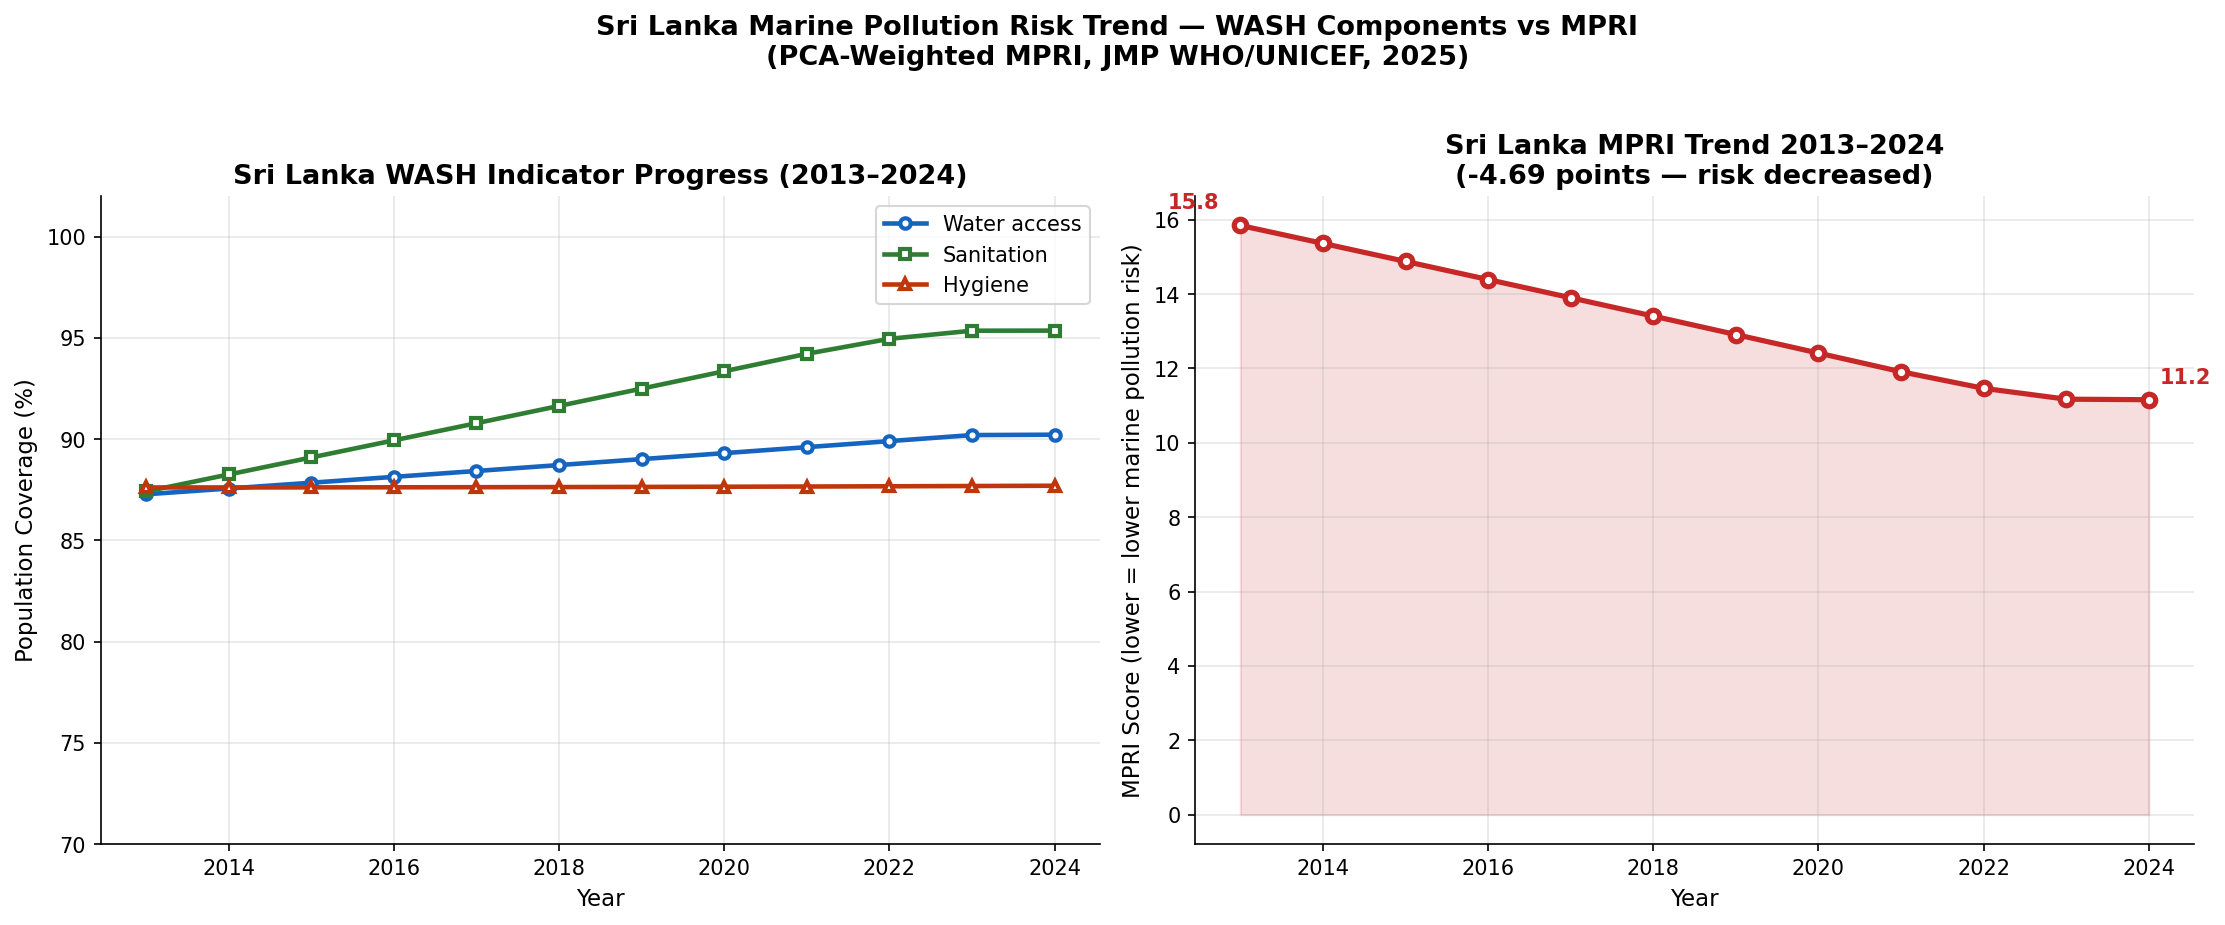

Saved: figures/fig9_srilanka_mpri_trend.png


In [9]:
# ── CELL 9: Figure 9 — Sri Lanka MPRI time-series (2013-2024) ─
# Compute MPRI for Sri Lanka across all years where all 3 indicators exist

sl_ts = sl[sl['year'] >= 2013].dropna(
    subset=['wat_basal_t','san_basal_t','hyg_bas_t']
).copy().sort_values('year')

# Apply same PCA weights to compute MPRI for each year
sl_ts['MPRI_raw'] = (
    weights[0] * (100 - sl_ts['wat_basal_t']) +
    weights[1] * (100 - sl_ts['san_basal_t']) +
    weights[2] * (100 - sl_ts['hyg_bas_t'])
)

# Scale relative to global 2024 min/max so scores are comparable
sl_ts['MPRI'] = scaler_mpri.transform(sl_ts[['MPRI_raw']]).flatten()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Sri Lanka Marine Pollution Risk Trend — WASH Components vs MPRI\n'
             '(PCA-Weighted MPRI, JMP WHO/UNICEF, 2025)',
             fontsize=13, fontweight='bold', y=1.02)

# Panel A: All 3 WASH indicators stacked on one chart
ax = axes[0]
ax.plot(sl_ts['year'], sl_ts['wat_basal_t'], 'o-',
        color='#1565C0', linewidth=2.2, markersize=5,
        markerfacecolor='white', markeredgewidth=2, label='Water access')
ax.plot(sl_ts['year'], sl_ts['san_basal_t'], 's-',
        color='#2E7D32', linewidth=2.2, markersize=5,
        markerfacecolor='white', markeredgewidth=2, label='Sanitation')
ax.plot(sl_ts['year'], sl_ts['hyg_bas_t'], '^-',
        color='#BF360C', linewidth=2.2, markersize=5,
        markerfacecolor='white', markeredgewidth=2, label='Hygiene')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Population Coverage (%)', fontsize=11)
ax.set_title('Sri Lanka WASH Indicator Progress (2013–2024)', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)
ax.set_ylim(70, 102)

# Panel B: MPRI trend — decreasing = improving
ax = axes[1]
ax.fill_between(sl_ts['year'], sl_ts['MPRI'], alpha=0.15, color='#C62828')
ax.plot(sl_ts['year'], sl_ts['MPRI'], 'o-', color='#C62828',
        linewidth=2.5, markersize=6, markerfacecolor='white',
        markeredgewidth=2.5, label='MPRI')

# Annotate first and last
ax.annotate(f"{sl_ts['MPRI'].iloc[0]:.1f}",
            (sl_ts['year'].iloc[0], sl_ts['MPRI'].iloc[0]),
            xytext=(-35, 8), textcoords='offset points',
            fontsize=10, fontweight='bold', color='#C62828')
ax.annotate(f"{sl_ts['MPRI'].iloc[-1]:.1f}",
            (sl_ts['year'].iloc[-1], sl_ts['MPRI'].iloc[-1]),
            xytext=(5, 8), textcoords='offset points',
            fontsize=10, fontweight='bold', color='#C62828')

mpri_change = sl_ts['MPRI'].iloc[-1] - sl_ts['MPRI'].iloc[0]
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('MPRI Score (lower = lower marine pollution risk)', fontsize=11)
ax.set_title(f'Sri Lanka MPRI Trend 2013–2024\n'
             f'({mpri_change:+.2f} points — risk {"increased" if mpri_change>0 else "decreased"})',
             fontweight='bold')
ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig9_srilanka_mpri_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig9_srilanka_mpri_trend.png")

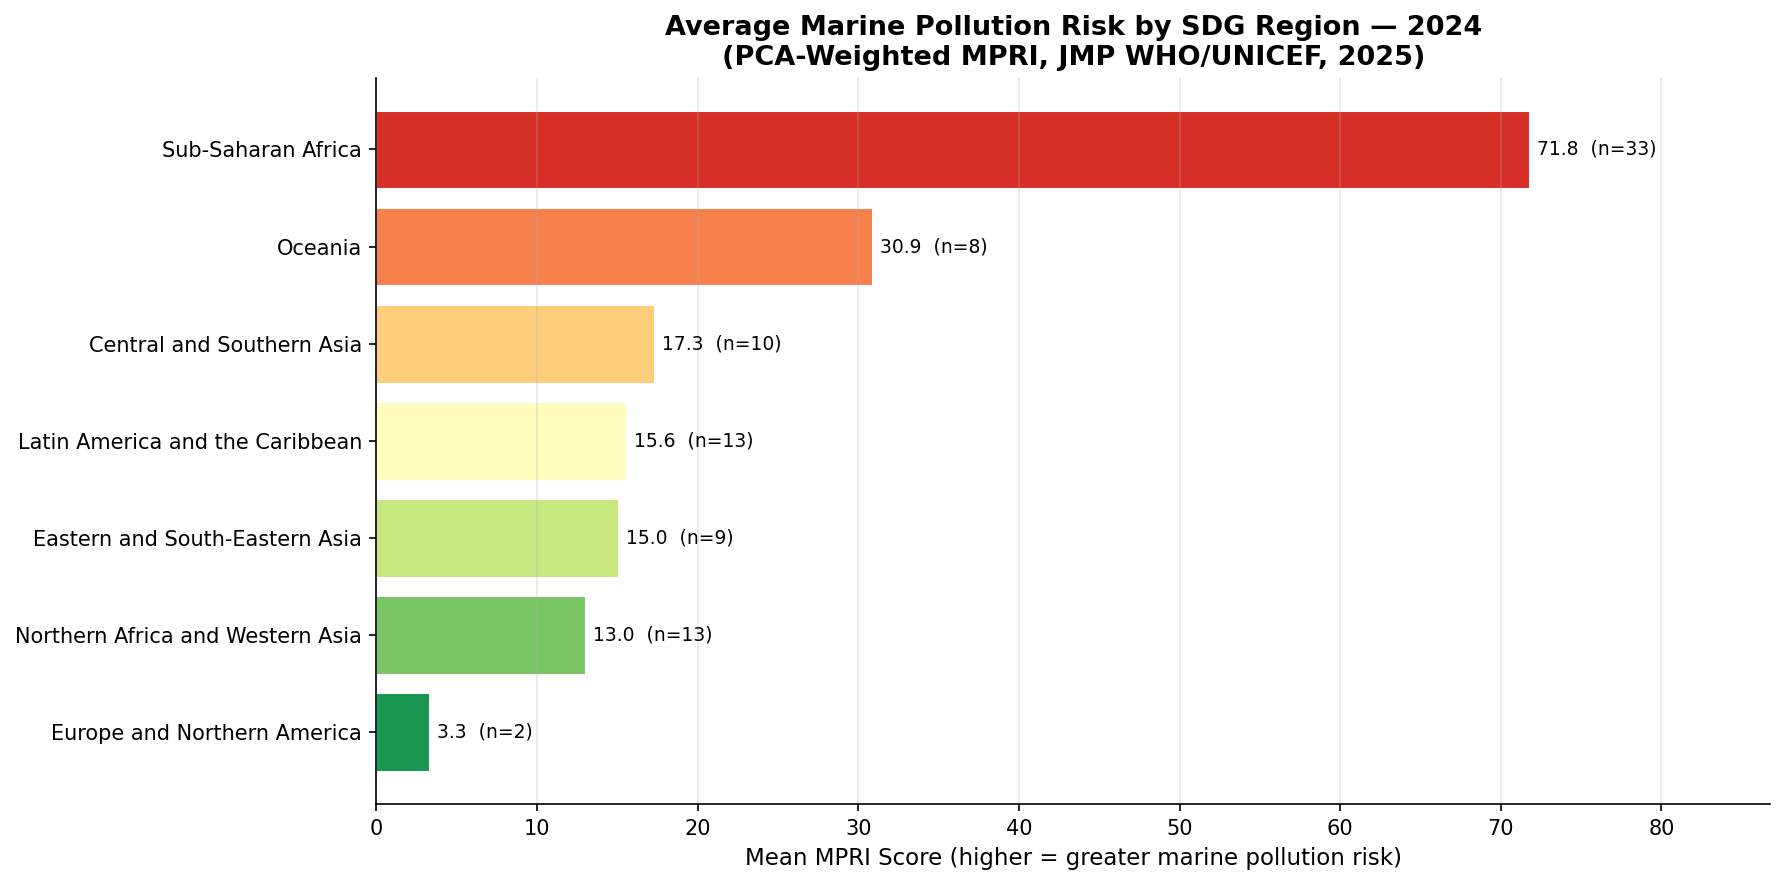

Saved: figures/fig10_regional_mpri.png


In [10]:
# ── CELL 10: Figure 10 — Regional risk map (no geopandas needed)
# Bar chart showing average MPRI by SDG region — clean alternative

region_mpri = df_ml.groupby('region_sdg').agg(
    mean_MPRI  = ('MPRI', 'mean'),
    n_countries = ('name', 'count')
).sort_values('mean_MPRI', ascending=True).reset_index()

region_colors = plt.cm.RdYlGn_r(
    np.linspace(0.1, 0.9, len(region_mpri))
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(region_mpri['region_sdg'], region_mpri['mean_MPRI'],
               color=region_colors, edgecolor='white', linewidth=0.5)

# Annotate with country count
for bar, row in zip(bars, region_mpri.itertuples()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{row.mean_MPRI:.1f}  (n={row.n_countries})',
            va='center', fontsize=9)

ax.set_xlabel('Mean MPRI Score (higher = greater marine pollution risk)', fontsize=11)
ax.set_title('Average Marine Pollution Risk by SDG Region — 2024\n'
             '(PCA-Weighted MPRI, JMP WHO/UNICEF, 2025)',
             fontweight='bold')
ax.set_xlim(0, region_mpri['mean_MPRI'].max() + 15)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig10_regional_mpri.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig10_regional_mpri.png")

In [11]:
# ── CELL 11: Save outputs for Notebook 3 ─────────────────────
df_ml.to_csv('../outputs/dataset_with_mpri.csv', index=False)

# Print complete summary for your paper
print("=" * 60)
print("NOTEBOOK 2 COMPLETE — Results Summary for Paper")
print("=" * 60)
print(f"\nMPRI Construction:")
print(f"  Water weight     : {weights[0]:.4f} ({weights[0]*100:.1f}%)")
print(f"  Sanitation weight: {weights[1]:.4f} ({weights[1]*100:.1f}%)")
print(f"  Hygiene weight   : {weights[2]:.4f} ({weights[2]*100:.1f}%)")
print(f"  PC1 variance     : {pca.explained_variance_ratio_[0]*100:.1f}%")

print(f"\nClustering:")
print(f"  Algorithm   : K-Means (k=3)")
print(f"  Silhouette  : {final_sil:.4f}")
print(f"  n countries : {len(df_ml)}")
for r in ['Low Risk','Medium Risk','High Risk']:
    n = len(df_ml[df_ml['risk_category']==r])
    m = df_ml[df_ml['risk_category']==r]['MPRI'].mean()
    print(f"  {r:<15}: {n} countries, mean MPRI = {m:.1f}")

print(f"\nSri Lanka:")
print(f"  Risk category: {sl_risk}")
print(f"  MPRI score   : {sl_mpri_score:.2f}")
print(f"  Global rank  : {int(sl_rank)} of {len(df_ml)}")

print(f"\nFigures saved (fig6 to fig10):")
for i in range(6, 11):
    print(f"  figures/fig{i}_*.png")

print(f"\nOutputs saved:")
print(f"  outputs/dataset_with_mpri.csv")
print(f"\nOpen 03_ml_models.ipynb next.")

NOTEBOOK 2 COMPLETE — Results Summary for Paper

MPRI Construction:
  Water weight     : 0.2692 (26.9%)
  Sanitation weight: 0.3630 (36.3%)
  Hygiene weight   : 0.3678 (36.8%)
  PC1 variance     : 90.2%

Clustering:
  Algorithm   : K-Means (k=3)
  Silhouette  : 0.5997
  n countries : 88
  Low Risk       : 49 countries, mean MPRI = 11.6
  Medium Risk    : 24 countries, mean MPRI = 59.4
  High Risk      : 15 countries, mean MPRI = 87.2

Sri Lanka:
  Risk category: Low Risk
  MPRI score   : 11.16
  Global rank  : 61 of 88

Figures saved (fig6 to fig10):
  figures/fig6_*.png
  figures/fig7_*.png
  figures/fig8_*.png
  figures/fig9_*.png
  figures/fig10_*.png

Outputs saved:
  outputs/dataset_with_mpri.csv

Open 03_ml_models.ipynb next.
